In [1]:
import torchvision

trainset=torchvision.datasets.CIFAR10(root=r'.', 
                          train=True, download=True)

100.0%


In [46]:
import math

In [2]:
# Names of the ten types of objects
names = ['plane', 'car', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']

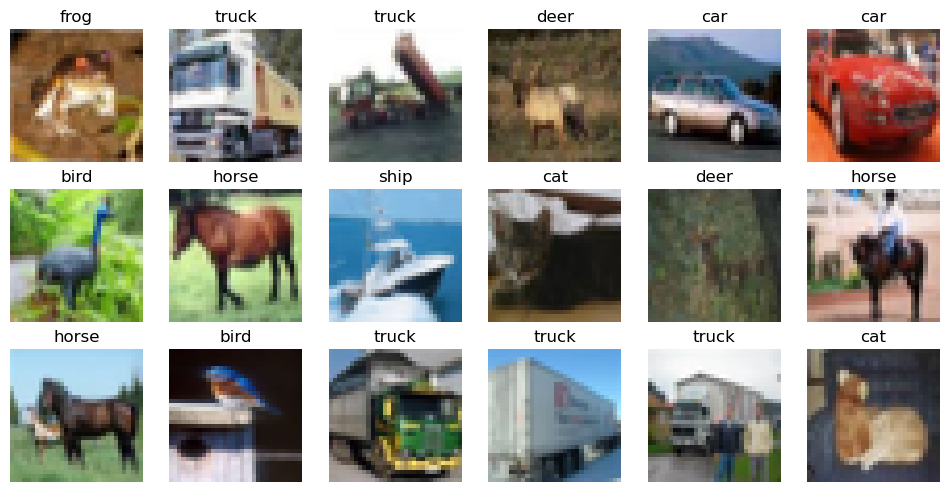

In [3]:
import matplotlib.pyplot as plt
import numpy as np 
# Create a 3 by 6 grid of pictures
plt.figure(figsize=(12,6),dpi=100)
for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(trainset[6*i+j][0])
        plt.axis('off')
        plt.title(names[trainset[6*i+j][1]], fontsize=12)
plt.subplots_adjust(hspace=0.20)
plt.show()

In [5]:
testset=torchvision.datasets.CIFAR10(root=r'.', train=False, download=True)

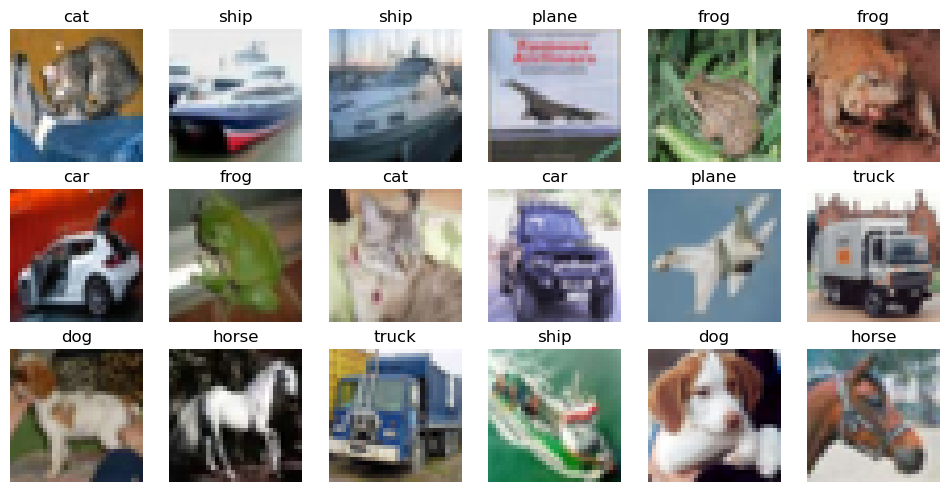

In [6]:
plt.figure(figsize=(12,6),dpi=100)
for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(testset[6*i+j][0])
        plt.axis('off')
        plt.title(names[testset[6*i+j][1]], fontsize=12)
plt.subplots_adjust(hspace=0.20)
plt.show()

In [7]:
import torchvision.transforms as transforms

trainset.transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((32, 32),antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0),
                 ratio=(0.75, 1.3333333333333333), 
                 interpolation=2,antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [8]:
import torch

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

In [9]:
testset.transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((32, 32),antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
testloader = torch.utils.data.DataLoader(testset, batch_size=32,shuffle=False)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
class Config:
    patch_size=4 
    hidden_size=48
    num_hidden_layers=4
    num_attention_heads=4
    intermediate_size= 4 * 48
    image_size=32
    num_classes=10 
    num_channels=3
config=Config()

In [12]:
print(config.hidden_size) 
print(config.num_classes) 

48
10


In [14]:
import torch.nn as nn

In [47]:
class PatchEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.projection = nn.Conv2d(config.num_channels,
                                    config.hidden_size, 
                                    kernel_size=config.patch_size, 
                                    stride=config.patch_size)
    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x  

In [48]:
patchembed=PatchEmbeddings(config)
# create a hypothetical image
img=torch.randn((1,3,32,32))
# pass a batch of one image through the class
out=patchembed(img)
# print out the shape of the output
print(out.shape)

torch.Size([1, 64, 48])


In [49]:
img5=torch.randn((5,3,32,32))
out5=patchembed(img5)
print(out5.shape) 
# torch.Size([5, 64, 48]) 5 images in the batch
# each image is divided into 64 patches. 
# Each patch is represented by a 48-value vector.

torch.Size([5, 64, 48])


In [50]:
32*32/64

16.0

In [51]:
#now each patch has 3 channels
16*3 #in essence 4x4x3

48

In [52]:
class Embeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embeddings = PatchEmbeddings(config)    
        self.cls_token = nn.Parameter(torch.randn(1, 1, config.hidden_size))  
        num_patches = (config.image_size // config.patch_size) ** 2
        self.position_embeddings = \
        nn.Parameter(torch.randn(1,num_patches+1,config.hidden_size))  
    def forward(self, x):
        x = self.patch_embeddings(x)
        batch_size, _, _ = x.size()
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.position_embeddings
        return x  

In [53]:
embed=Embeddings(config)
# create a hypothetical image
img=torch.randn((1,3,32,32))
# pass a batch of one image through the class
out=embed(img)
# the shapes of the output
print(out.shape)
# the shapes of the positional encoding
print(embed.position_embeddings.shape)

torch.Size([1, 65, 48])
torch.Size([1, 65, 48])


In [54]:
class AttentionHead(nn.Module):
    def __init__(self, hidden_size, attention_head_size, bias=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.attention_head_size = attention_head_size
        self.query = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.key = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.value = nn.Linear(hidden_size, attention_head_size, bias=bias)   
    def forward(self, x):
        query = self.query(x)
        key = self.key(x)
        value = self.value(x)
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(\
                self.attention_head_size)
        attention_probs = nn.functional.softmax(attention_scores, dim=-1)
        attention_output = torch.matmul(attention_probs, value)
        return (attention_output, attention_probs)

In [55]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = \
        self.hidden_size // self.num_attention_heads
        self.all_head_size = \
        self.num_attention_heads * self.attention_head_size
        self.heads = nn.ModuleList([])
        for _ in range(self.num_attention_heads):
            head = AttentionHead(
                self.hidden_size,
                self.attention_head_size)
            self.heads.append(head)
        self.output_projection = nn.Linear(self.all_head_size,\
                                           self.hidden_size) 
    def forward(self, x, output_attentions=False):
        attention_outputs = [head(x) for head in self.heads]
        attention_output = torch.cat([attention_output for attention_output,
                                      _ in attention_outputs], dim=-1)
        attention_output = self.output_projection(attention_output)
        if not output_attentions:
            return (attention_output, None)
        else:
            attention_probs = torch.stack([attention_probs for _, 
                           attention_probs in attention_outputs], dim=1)
            return (attention_output, attention_probs)

In [56]:
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense_1 = nn.Linear(config.hidden_size,
                                 config.intermediate_size)
        self.activation = nn.GELU()
        self.dense_2 = nn.Linear(config.intermediate_size,
                                 config.hidden_size)
    def forward(self, x):
        x = self.dense_1(x)
        x = self.activation(x)
        x = self.dense_2(x)
        return x

In [57]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        self.layernorm_1 = nn.LayerNorm(config.hidden_size)
        self.mlp = MLP(config)
        self.layernorm_2 = nn.LayerNorm(config.hidden_size)
    def forward(self, x, output_attentions=False):
        attention_output, attention_probs = \
        self.attention(self.layernorm_1(x),
                       output_attentions=output_attentions)
        x = x + attention_output
        mlp_output = self.mlp(self.layernorm_2(x))
        x = x + mlp_output  
        if not output_attentions:
            return (x, None)
        else:
            return (x, attention_probs)

In [58]:
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.blocks = nn.ModuleList([])
        for _ in range(config.num_hidden_layers):
            block = Block(config)
            self.blocks.append(block)
    def forward(self, x, output_attentions=False):
        all_attentions = []
        for block in self.blocks:
            x, attention_probs = block(x, 
               output_attentions=output_attentions)
            if output_attentions:
                all_attentions.append(attention_probs)
        if not output_attentions:
            return (x, None)
        else:
            return (x, all_attentions)

In [59]:
class ViTForClassfication(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.image_size = config.image_size
        self.hidden_size = config.hidden_size
        self.num_classes = config.num_classes
        self.embedding = Embeddings(config)
        self.encoder = Encoder(config)
        self.classifier = nn.Linear(self.hidden_size,
                                    self.num_classes)
        self.apply(self._init_weights)
    def forward(self, x, output_attentions=False):
        embedding_output = self.embedding(x)
        encoder_output, all_attentions = self.encoder(\
          embedding_output,output_attentions=output_attentions)
        logits = self.classifier(encoder_output[:, 0, :])
        if not output_attentions:
            return (logits, None)
        else:
            return (logits, all_attentions)
    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)
        elif isinstance(module, Embeddings):
            module.position_embeddings.data = nn.init.trunc_normal_(
                module.position_embeddings.data.to(torch.float32),
                mean=0.0,std=0.02,).to(module.position_embeddings.dtype)
            module.cls_token.data = nn.init.trunc_normal_(
                module.cls_token.data.to(torch.float32),
                mean=0.0,std=0.02,).to(module.cls_token.dtype)

In [60]:
model = ViTForClassfication(config).to(device)

In [61]:
model

ViTForClassfication(
  (embedding): Embeddings(
    (patch_embeddings): PatchEmbeddings(
      (projection): Conv2d(3, 48, kernel_size=(4, 4), stride=(4, 4))
    )
  )
  (encoder): Encoder(
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-3): 4 x AttentionHead(
              (query): Linear(in_features=48, out_features=12, bias=True)
              (key): Linear(in_features=48, out_features=12, bias=True)
              (value): Linear(in_features=48, out_features=12, bias=True)
            )
          )
          (output_projection): Linear(in_features=48, out_features=48, bias=True)
        )
        (layernorm_1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=48, out_features=192, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_features=192, out_features=48, bias=True)
        )
        (la

In [62]:
from torch import optim

optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-2)

In [63]:
loss_fn = nn.CrossEntropyLoss()

In [64]:
scaler = torch.amp.GradScaler()

In [65]:
class EarlyStop:
    def __init__(self, patience=3):    
        self.patience = patience
        self.steps = 0
        self.min_loss = float('inf')
    def stop(self, loss):    
        if loss < self.min_loss:    
            self.min_loss = loss
            self.steps = 0
            to_save = True
        elif loss >= self.min_loss:
            self.steps += 1
            to_save = False
        if self.steps >= self.patience:    
            to_stop = True
        else:
            to_stop = False
        return to_save, to_stop

stopper=EarlyStop()

In [66]:
def train_batch(batch):
    batch = [t.to(device) for t in batch]
    images, labels = batch
    with torch.amp.autocast(device):
        loss = loss_fn(model(images)[0], labels)
    optimizer.zero_grad() 
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()        
    return loss.item()*len(images)/len(trainloader.dataset)

In [67]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable


In [68]:
from tqdm import tqdm
import os
os.makedirs("files", exist_ok=True)
for i in range(100):
    print(f'Epoch {i+1}')
    model.train()
    trainL, testL = 0, 0
    for batch in tqdm(trainloader):
        loss=train_batch(batch)      
        trainL+=loss
    model.eval()
    with torch.no_grad():
        for batch in testloader:
            batch = [t.to(device) for t in batch]
            images, labels = batch
            logits, _ = model(images)
            loss = loss_fn(logits, labels)
            testL+=loss.item()*len(images)/len(testloader.dataset)
    print(f'Train and test losses: {trainL:.4f}, {testL:.4f}')
    to_save, to_stop = stopper.stop(testL)
    if to_save==True:    
        torch.save(model.state_dict(),"files/ViT.pth")
    if to_stop==True:    
        break

Epoch 1


100%|██████████| 1563/1563 [01:22<00:00, 19.03it/s]


Train and test losses: 1.8417, 1.6095
Epoch 2


100%|██████████| 1563/1563 [01:25<00:00, 18.28it/s]


Train and test losses: 1.5580, 1.5123
Epoch 3


...

Train and test losses: 1.1973, 1.2038
Epoch 12


100%|██████████| 1563/1563 [01:20<00:00, 19.53it/s]


Train and test losses: 1.1870, 1.2050
Epoch 13


100%|██████████| 1563/1563 [01:27<00:00, 17.92it/s]


Train and test losses: 1.1713, 1.1788


In [69]:
import math
import torch.nn.functional as F  

model.load_state_dict(torch.load('files/ViT.pth'))    
model.eval()
with torch.no_grad():
    batch=next(iter(testloader))    
    batch = [t.to(device) for t in batch]
    images, labels = batch
    logits, attention_maps = model(images, output_attentions=True)
    predictions = torch.argmax(logits, dim=1)    

print(predictions)
print([names[i] for i in predictions.tolist()])

tensor([3, 1, 1, 0, 6, 6, 1, 6, 3, 1, 0, 9, 3, 7, 9, 6, 3, 7, 8, 6, 7, 0, 0, 1,
        4, 2, 4, 0, 1, 6, 6, 5], device='cuda:0')
['cat', 'car', 'car', 'plane', 'frog', 'frog', 'car', 'frog', 'cat', 'car', 'plane', 'truck', 'cat', 'horse', 'truck', 'frog', 'cat', 'horse', 'ship', 'frog', 'horse', 'plane', 'plane', 'car', 'deer', 'bird', 'deer', 'plane', 'car', 'frog', 'frog', 'dog']


In [70]:
# attention_maps is a list of four attention maps
# each attention map stores attention probabilities in an encoder block
for attn in attention_maps:
    print(attn.shape)
block0_image0_head0=attention_maps[0][0,0,:,:]
print(block0_image0_head0.shape)
probs_sum=torch.sum(block0_image0_head0,dim=1)
print(probs_sum)  

torch.Size([32, 4, 65, 65])
torch.Size([32, 4, 65, 65])
torch.Size([32, 4, 65, 65])
torch.Size([32, 4, 65, 65])
torch.Size([65, 65])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000], device='cuda:0')


attention map shape: torch.Size([32, 16, 65, 65])
attention map shape: torch.Size([32, 16, 64])
attention map shape: torch.Size([32, 64])
attention map shape: torch.Size([32, 8, 8])
attention map shape: torch.Size([32, 32, 32])


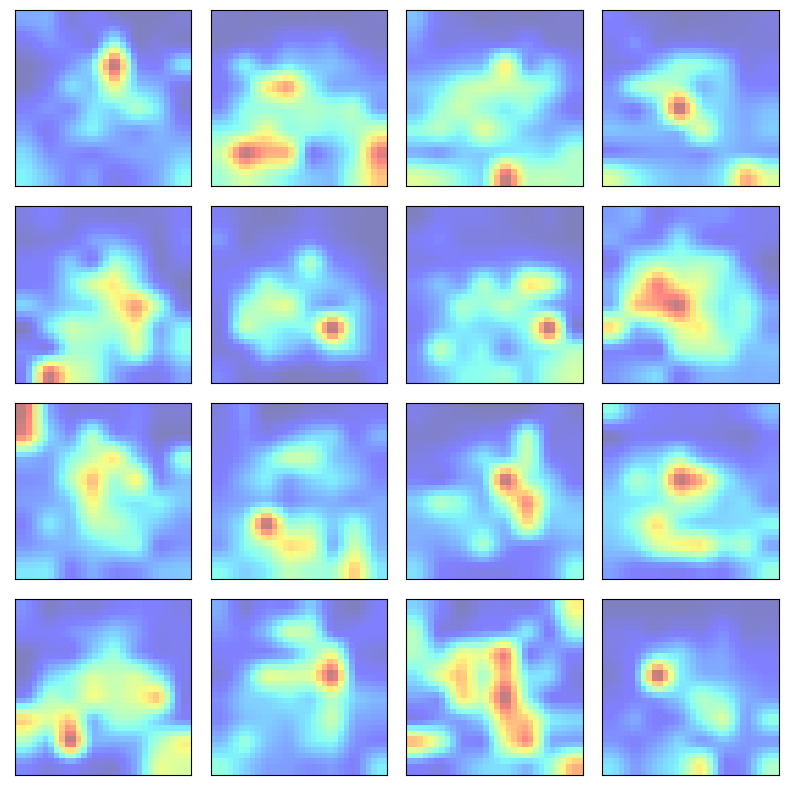

In [71]:
with torch.no_grad():
    attention_maps = torch.cat(attention_maps, dim=1)
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps[:, :, 0, 1:]
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps.mean(dim=1)
    print(f"attention map shape: {attention_maps.shape}")
    num_patches = attention_maps.size(-1)
    size = int(math.sqrt(num_patches))
    attention_maps = attention_maps.view(-1, size, size)
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps.unsqueeze(1)
    attention_maps = F.interpolate(attention_maps, size=(32, 32),
                       mode='bilinear', align_corners=False)
    attention_maps = attention_maps.squeeze(1)    #D
    print(f"attention map shape: {attention_maps.shape}")

fig = plt.figure(figsize=(8, 8),dpi=100)
for i in range(16):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    ax.imshow(attention_maps[i].cpu(), alpha=0.5, cmap='jet')
plt.tight_layout()
plt.show() 

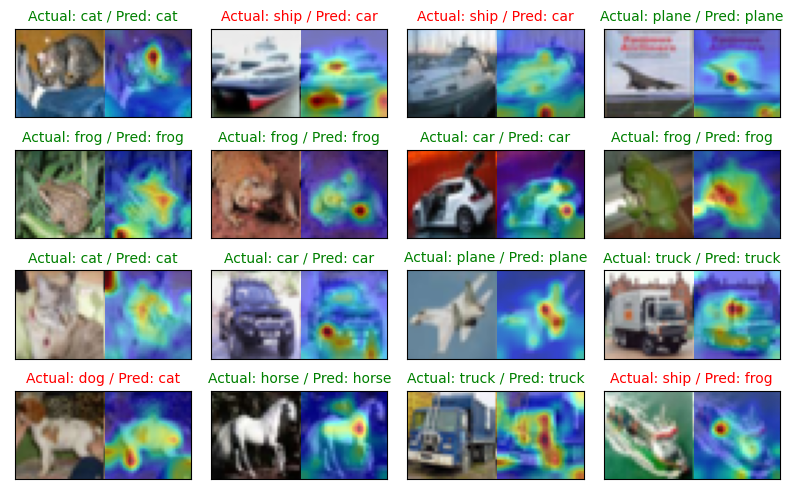

In [72]:
fig = plt.figure(figsize=(8, 5),dpi=100)
mask = np.concatenate([np.ones((32, 32)), np.zeros((32, 32))],
                      axis=1)
for i in range(16):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    img = np.concatenate((images[i].cpu(), images[i].cpu()),
                         axis=-1)
    ax.imshow(img.transpose(1,2,0)/2+0.5)
    extended_attention_map = np.concatenate((np.zeros((32, 32)), 
                                     attention_maps[i].cpu()),
                                            axis=1)
    extended_attention_map = np.ma.masked_where(mask==1,
                                    extended_attention_map)
    ax.imshow(extended_attention_map, alpha=0.5, cmap='jet')
    gt = names[labels[i]]
    pred = names[predictions[i]]    
    ax.set_title(f"Actual: {gt} / Pred: {pred}", 
                 color=("green" if gt==pred else "red"),
                fontsize=10)
plt.tight_layout()
plt.show() 

In [75]:
model.eval()
acc = 0
with torch.no_grad():
    for batch in trainloader:
        batch = [t.to(device) for t in batch]
        images, labels = batch
        logits, _ = model(images)
        predictions = torch.argmax(logits, dim=1)
        acc += torch.sum(predictions ==\
             labels).item()/ len(trainloader.dataset)
print(f'the prediction accuracy is {acc:.4f}')

the prediction accuracy is 0.5830


In [76]:
model.eval()
acc = 0
with torch.no_grad():
    for batch in testloader:
        batch = [t.to(device) for t in batch]
        images, labels = batch
        logits, _ = model(images)
        predictions = torch.argmax(logits, dim=1)
        acc += torch.sum(predictions ==\
             labels).item()/ len(testloader.dataset)
print(f'the prediction accuracy is {acc:.4f}')

the prediction accuracy is 0.5864


This is pretty neat. We have 10 classes so a random guessing model will have 10% accuracy. Ours have close to 60%. This means our model is training. It is just that it requires more training time and more data - we know that transformers are data hungry. and somehow the model we created is very small to capture details of cifar10 dataset - its pretty complex dataset

In [78]:
sum(p.numel() for p in model.parameters())

119098